In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import bbrl_utils
from bbrl_utils.notebook import setup_tensorboard
from bbrl.stats import WelchTTest

import gymnasium as gym
import bbrl_gymnasium

from pmind.algorithms import DQN, DDPG, TD3
from pmind.losses import dqn_compute_critic_loss, ddqn_compute_critic_loss
from pmind.training import run_dqn, run_ddpg, run_td3
from pmind.config.loader import load_config

bbrl_utils.setup()

%load_ext autoreload
%autoreload 2

/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/bbrl_utils/notebook.py:46: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # noqa: F401
Using Python 3.10.18 environment at: /Users/vlad/Documents/University/Master-MIND/projet-mind/.venv


In [2]:
ENV_NAME = "MountainCarContinuous-v0"

In [352]:
intermediate_policies = torch.load(f"../models/{ENV_NAME}/intermediate-policies.pt", weights_only=False)
intermediate_policies.append(torch.load(f"../models/{ENV_NAME}/best-policy.pt", weights_only=False))

intermediate_policies = [item for item in intermediate_policies if item is not None]

In [353]:
env = gym.make(ENV_NAME)

In [354]:
state_space = np.array([env.observation_space.low, env.observation_space.high]).T

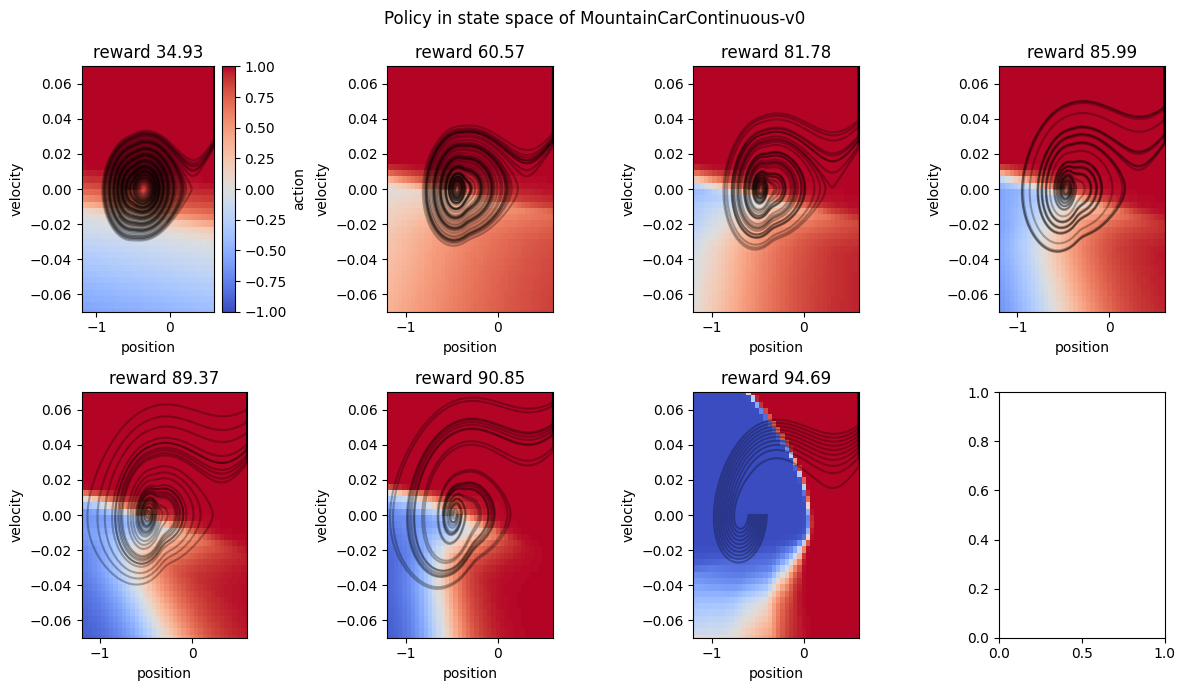

In [355]:
TRAJECTORY_LENGTH = 999
N_TRAJECTORIES = 10
start_states = np.vstack([np.linspace(-0.6, -0.4, N_TRAJECTORIES), np.zeros(N_TRAJECTORIES)]).T

fig, axes = plt.subplots(2, 4, figsize=(12,7))
axes = axes.flatten()
for i, item in enumerate(intermediate_policies):
    if item is None:
        continue
    reward, policy = item

    grid_density = 40
    x = np.linspace(*state_space[0],num=grid_density)
    y = np.linspace(*state_space[1],num=grid_density)
    X, Y = np.meshgrid(x, y)

    axes[i].set_xlim(state_space[0])

    axes[i].set_xlabel("position")
    axes[i].set_ylim(state_space[1])

    axes[i].set_ylabel("velocity")

    Z = np.empty((grid_density, grid_density))
    for i_x in range(len(x)):
        for i_y in range(len(y)):
            Z[i_x, i_y] = policy.model(torch.tensor([[x[i_x], y[i_y]]]).float()).item() 
            # plt.scatter(x,y, c=action, cmap="coolwarm", vmin=-1, vmax=1)
            
    cntr = axes[i].pcolormesh(X,Y,Z,cmap="coolwarm", vmin=-1, vmax=1)
    if i==0:
        cbar = fig.colorbar(cntr,ax=axes[i])
        cbar.set_label("action")
    
    for t in range(N_TRAJECTORIES):
        
        trajectory = np.empty((env.observation_space.shape[0], TRAJECTORY_LENGTH))
        _, _ = env.reset()
        state = start_states[t]
        env.state = env.unwrapped.state = state
        trajectory[:,0] = state
        for j in range(TRAJECTORY_LENGTH -1):
            action = np.array([policy.model(torch.tensor(state).float()).item()])
            state, *_ = env.step(action)
            trajectory[:,j+1] = state

        axes[i].plot(trajectory[0], trajectory[1], c="black", alpha=0.3)
        axes[i].set_title(f"reward {reward:.2f}")

plt.suptitle(f"Policy in state space of {ENV_NAME}")
plt.tight_layout()
plt.show()

In [356]:
policy

ContinuousDeterministicActor(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=300, bias=True)
    (3): ReLU()
    (4): Linear(in_features=300, out_features=1, bias=True)
    (5): Tanh()
  )
)